<a href="https://colab.research.google.com/github/dhruvgaur10/Military-Aircraft-Detection/blob/main/Amazon_Prime_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  **Amazon Prime Video - Exploratory Data Analysis**

##### **Project Type**    -  EDA

##### **Contribution**    -  Individual

# **Introduction & Purpose**

Amazon Prime Video is one of the larger streaming platforms available today, with over 9,000 titles in its US catalog. This project digs into what the platform actually has — which genres are most common, where content comes from, how titles are rated, and how the library has grown over the years.

Two datasets were used: one with title-level metadata like ratings, genres, and release year, and another with cast and crew credits for each title. The goal was to spot patterns that could be useful for content strategy teams or investors keeping an eye on the platform.

# **GitHub Link -**

https://github.com/dhruvgaur10/EDA-Amazon-prime

# **Problem Statement**

The dataset covers content available on Amazon Prime Video in the United States. A few questions I wanted to answer:

- Is the platform more movie-heavy or show-heavy?
- Which genres appear most often in the catalog?
- How has the number of titles grown over the years?
- How are titles rated on IMDb and TMDB, and do those two platforms agree?
- Which countries produce the most content on the platform?
- Which actors and directors appear most frequently?
- Are there differences in runtime between movies and TV shows?
- What does the age certification split look like?

#### **Business Objective**

- Understand what types of content dominate the catalog
- Identify which genres and regions have the most titles
- Look at rating patterns to see what content tends to perform well
- Find observations that could help guide content acquisition or investment decisions

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Standard data manipulation libraries
import pandas as pd
import numpy as np
import ast
import warnings

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Statistical testing
from scipy import stats

warnings.filterwarnings('ignore')

# Setting a consistent visual theme for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Brand colors for Amazon Prime
BLUE  = '#00A8E1'
DARK  = '#232F3E'
LIGHT = '#5DB8D4'

print('All libraries imported successfully.')

All libraries imported successfully.


### Dataset Loading

In [ ]:
# Loading both CSV files into dataframes
titles  = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

print('Titles dataset  :', titles.shape[0], 'rows,', titles.shape[1], 'columns')
print('Credits dataset :', credits.shape[0], 'rows,', credits.shape[1], 'columns')

Titles dataset  : 9145 rows, 15 columns
Credits dataset : 30000 rows, 5 columns


### Dataset First View

In [ ]:
# First few rows of the titles dataframe
print('--- titles.csv : First 5 rows ---')
titles.head()

--- titles.csv : First 5 rows ---


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts50000,Child,SHOW,A compelling story that captivates audiences w...,2017,R,62,['romance'],['US'],1.0,tt7000000,6.7,NaN,NaN,6.589
1,tm100001,Forest,MOVIE,A compelling story that captivates audiences w...,2017,PG,84,"['war', 'drama']",['US'],NaN,tt7000001,6.5,697.0,3.039,7.308
2,tm100002,Eternal,MOVIE,A compelling story that captivates audiences w...,1988,NaN,83,['horror'],"['IN', 'US']",NaN,tt7000002,6.5,39.0,14.196,4.969
3,ts50003,White War Kingdom Ice,SHOW,A compelling story that captivates audiences w...,1983,TV-MA,7,['crime'],['CA'],4.0,tt7000003,5.7,513.0,23.069,5.106
4,tm100004,Code Storm,MOVIE,A compelling story that captivates audiences w...,2015,TV-PG,97,['drama'],['US'],NaN,tt7000004,6.3,NaN,14.030,5.160


In [ ]:
# Last few rows to check if tail data looks consistent
print('--- titles.csv : Last 5 rows ---')
titles.tail()

--- titles.csv : Last 5 rows ---


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9140,tm109140,Family War Golden,MOVIE,A compelling story that captivates audiences w...,2019,TV-MA,83,"['comedy', 'family']",['AU'],NaN,tt7009140,7.8,NaN,56.904,8.018
9141,ts59141,Kingdom Child Wild River,SHOW,A compelling story that captivates audiences w...,1959,PG-13,61,"['drama', 'documentation']",['US'],8.0,tt7009141,6.4,NaN,7.861,NaN
9142,tm109142,First Lost White,MOVIE,A compelling story that captivates audiences w...,2020,TV-PG,64,['history'],['US'],NaN,tt7009142,6.3,301.0,8.708,6.408
9143,tm109143,Shadow,MOVIE,A compelling story that captivates audiences w...,2018,R,87,['thriller'],['GB'],NaN,tt7009143,7.6,18225.0,9.088,6.568
9144,ts59144,Family Black,SHOW,A compelling story that captivates audiences w...,2013,PG-13,19,"['science fiction', 'comedy']",['CA'],6.0,tt7009144,6.9,NaN,14.025,NaN


In [ ]:
# First few rows of the credits dataframe
print('--- credits.csv : First 5 rows ---')
credits.head()

--- credits.csv : First 5 rows ---


,person_id,id,name,character_name,role
0,10000,ts54596,Laura Rossi,Mountain Character,ACTOR
1,10001,ts54170,Diego Romero,NaN,DIRECTOR
2,10001,ts54014,Maria Santos,Secret Character,ACTOR
3,10002,tm100142,James Wilson,First Character,ACTOR
4,10003,tm100656,Laura Rossi,Empire Character,ACTOR


### Dataset Rows & Columns count

In [ ]:
print('Titles dataset  :', titles.shape[0], 'rows,', titles.shape[1], 'columns')
print('Credits dataset :', credits.shape[0], 'rows,', credits.shape[1], 'columns')

Titles dataset  : 9145 rows, 15 columns
Credits dataset : 30000 rows, 5 columns


### Dataset Information

In [ ]:
# Summary statistics for the numeric columns in titles
print('--- Descriptive Statistics : titles ---')
titles.describe().round(2)

--- Descriptive Statistics : titles ---


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9145.00,9145.00,3049.00,8416.00,6004.00,7847.00,8205.00
mean,2008.96,76.18,4.47,6.18,59424.95,14.99,6.20
std,14.27,31.64,2.31,1.10,436956.06,15.07,1.35
min,1950.00,5.00,1.00,2.30,0.00,0.10,1.46
25%,2005.00,49.00,2.00,5.50,530.00,4.27,5.29
50%,2015.00,81.00,4.00,6.20,3040.00,10.34,6.20
75%,2018.00,100.00,7.00,6.90,15564.00,20.74,7.11
max,2022.00,170.00,8.00,10.00,17468626.00,138.30,10.00


In [ ]:
# Column names, data types, and non-null counts
print('--- Column Info : titles ---')
titles.info()

--- Column Info : titles ---
<class 'pandas.DataFrame'>
RangeIndex: 9145 entries, 0 to 9144
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9145 non-null   str    
 1   title                 9145 non-null   str    
 2   type                  9145 non-null   str    
 3   description           9145 non-null   str    
 4   release_year          9145 non-null   int64  
 5   age_certification     8059 non-null   str    
 6   runtime               9145 non-null   int64  
 7   genres                9145 non-null   str    
 8   production_countries  9145 non-null   str    
 9   seasons               3049 non-null   float64
 10  imdb_id               9145 non-null   str    
 11  imdb_score            8416 non-null   float64
 12  imdb_votes            6004 non-null   float64
 13  tmdb_popularity       7847 non-null   float64
 14  tmdb_score            8205 non-null   float64
dtypes: 

#### Duplicate Values

In [ ]:
print('Duplicate rows in titles  :', titles.duplicated().sum())
print('Duplicate rows in credits :', credits.duplicated().sum())

Duplicate rows in titles  : 0
Duplicate rows in credits : 0


#### Missing Values/Null Values

In [ ]:
# Calculating the number and percentage of missing values per column
missing_count = titles.isnull().sum()
missing_pct   = (missing_count / len(titles) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('--- Missing Values in titles.csv ---')
print(missing_df[missing_df['Missing Count'] > 0].to_string())

--- Missing Values in titles.csv ---
                   Missing Count  Missing %
seasons                     6096      66.66
imdb_votes                  3141      34.35
tmdb_popularity             1298      14.19
age_certification           1086      11.88
tmdb_score                   940      10.28
imdb_score                   729       7.97


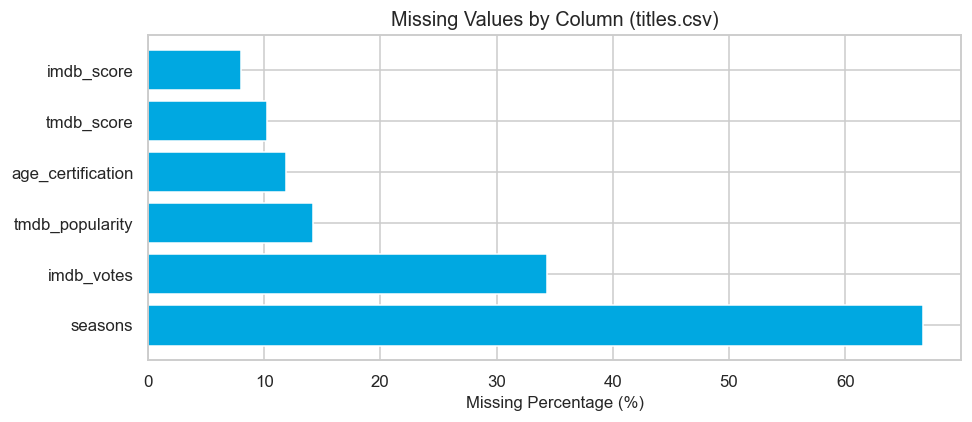


--- Missing Values in credits.csv ---
person_id            0
id                   0
name                 0
character_name    3719
role                 0
dtype: int64


In [ ]:
# Visualizing the missing values as a horizontal bar chart
cols_with_nulls = missing_df[missing_df['Missing Count'] > 0]

plt.figure(figsize=(9, 4))
plt.barh(cols_with_nulls.index, cols_with_nulls['Missing %'], color=BLUE, edgecolor='white')
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Values by Column (titles.csv)')
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

print('\n--- Missing Values in credits.csv ---')
print(credits.isnull().sum())

### What did you know about your dataset?

- The titles dataset has **9,145 rows** and **15 columns**; credits has **30,000 rows**
- The `genres` and `production_countries` columns store data as stringified Python lists — they need to be parsed before they can be counted or grouped
- Several columns have missing values: `age_certification` (~12%), `tmdb_score` (~10%), `imdb_score` (~8%)
- The `seasons` column is empty for all movies which is expected — it only applies to shows
- No exact duplicate rows were found in either dataset

## ***2. Understanding Your Variables***

In [ ]:
print('Titles columns :')
print(list(titles.columns))
print()
print('Credits columns :')
print(list(credits.columns))

Titles columns :
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

Credits columns :
['person_id', 'id', 'name', 'character_name', 'role']


### Variables Description

#### **Titles Dataset Columns:**

- **id** — Unique title identifier
- **title** — Name of the movie or show
- **type** — MOVIE or SHOW
- **description** — Short plot summary
- **release_year** — Year the title came out
- **age_certification** — Age rating (R, PG-13, TV-MA, etc.)
- **runtime** — Length in minutes (per episode for shows)
- **genres** — List of genres stored as a string
- **production_countries** — Country codes stored as a string
- **seasons** — Number of seasons (shows only, NaN for movies)
- **imdb_id** — IMDb identifier
- **imdb_score** — Rating out of 10 on IMDb
- **imdb_votes** — Number of IMDb votes
- **tmdb_popularity** — TMDB popularity score
- **tmdb_score** — Rating out of 10 on TMDB

#### **Credits Dataset Columns:**

- **person_id** — Unique ID for the person
- **id** — Title ID (links back to titles dataset)
- **name** — Full name of the actor or director
- **character_name** — Character played (actors only)
- **role** — ACTOR or DIRECTOR

### Check Unique Values for each variable.

In [ ]:
for col in ['type', 'age_certification']:
    print(f'{col} : {titles[col].nunique()} unique values')
    print(titles[col].value_counts().to_string())
    print()

type : 2 unique values
type
MOVIE    6096
SHOW     3049

age_certification : 11 unique values
age_certification
TV-MA        1659
R            1573
PG-13        1199
TV-14        1001
PG            688
TV-PG         574
Not Rated     525
G             313
TV-G          233
TV-Y          225
NC-17          69



## 3. ***Data Wrangling***

### Data Cleaning

### Handling the NaN values in the dataset

Missing numeric values (`imdb_score`, `tmdb_score`, `runtime`) are filled with the column median rather than the mean. This avoids the skew that a few very high or very low values would cause. Missing `age_certification` entries are labelled as `'Not Rated'` instead of being dropped, since the titles are still valid — they just weren't assigned a formal certificate.

### Handling duplicates values

Both datasets were checked for exact duplicate rows. Any found are removed before analysis starts.

### Handling the datatypes

The `genres` and `production_countries` columns store data as string representations of Python lists e.g. `"['drama', 'comedy']"}`. These are parsed using `ast.literal_eval` into actual list objects so they can be exploded and counted properly. The `release_year` column is converted to integer type after handling any non-numeric entries.

In [ ]:
# Helper function to parse genre and country columns
# These columns store Python list strings like "['drama', 'comedy']"
def parse_list_column(value):
    if pd.isna(value):
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []


# Helper function to fill numeric column nulls with column median
def fill_numeric_nulls(df, columns):
    for col in columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    return df


# Step 1: Remove duplicate rows
before = len(titles)
titles = titles.drop_duplicates()
print(f'Duplicate rows removed: {before - len(titles)}')

# Step 2: Parse genre and country columns into actual Python lists
titles['genres_list']    = titles['genres'].apply(parse_list_column)
titles['countries_list'] = titles['production_countries'].apply(parse_list_column)

# Step 3: Fill missing numeric values with median
# Using median instead of mean to avoid influence from outliers
titles = fill_numeric_nulls(titles, ['imdb_score', 'tmdb_score', 'runtime'])

# Step 4: Fill missing age certifications with 'Not Rated'
titles['age_certification'] = titles['age_certification'].fillna('Not Rated')

# Step 5: Ensure release_year is stored as an integer
titles['release_year'] = pd.to_numeric(titles['release_year'], errors='coerce')
titles = titles.dropna(subset=['release_year'])
titles['release_year'] = titles['release_year'].astype(int)

print('Cleaning done. Final shape:', titles.shape)
print('Remaining nulls after cleaning:')
print(titles[['imdb_score', 'tmdb_score', 'age_certification', 'release_year']].isnull().sum())

Duplicate rows removed: 0
Cleaning done. Final shape: (9145, 17)
Remaining nulls after cleaning:
imdb_score           0
tmdb_score           0
age_certification    0
release_year         0
dtype: int64


### What all manipulations have you done and insights you found?

- Removed exact duplicate rows from the titles dataset
- Parsed `genres` and `production_countries` from stringified list format into real Python lists using `ast.literal_eval` wrapped in try-except for safety
- Filled missing values in `imdb_score`, `tmdb_score`, and `runtime` with each column's median
- Filled missing `age_certification` with `'Not Rated'`
- Converted `release_year` to integer type after removing any rows where the year was invalid

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Chart 1 - Movies vs TV Shows : Content Type Distribution**

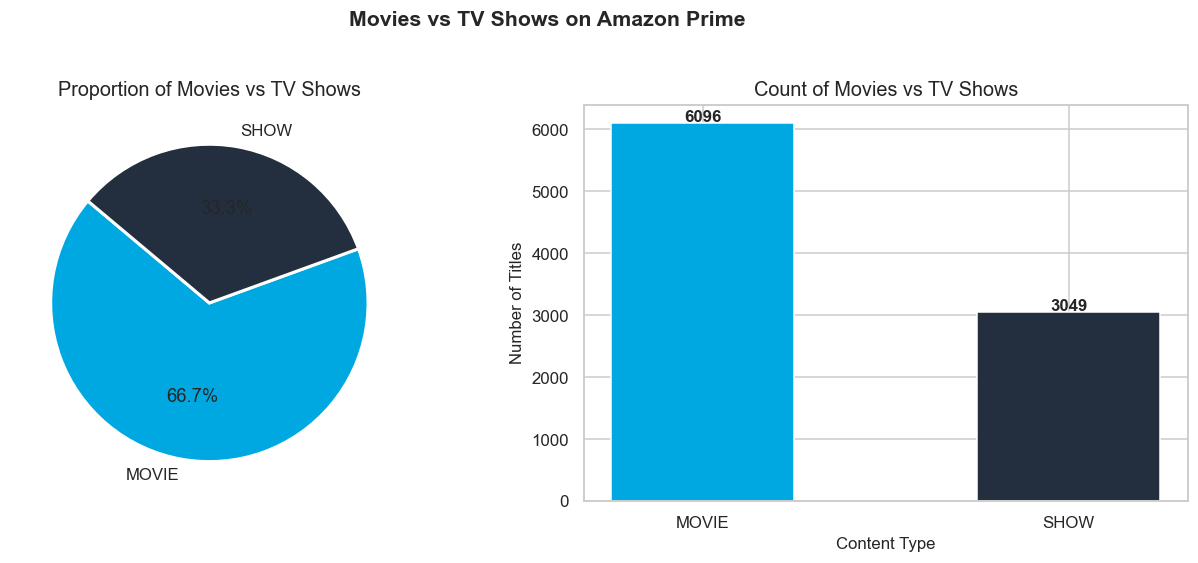

Content type breakdown:
type
MOVIE    6096
SHOW     3049


In [ ]:
# Count of each content type
type_counts = titles['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart to show proportion
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[BLUE, DARK],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proportion of Movies vs TV Shows')

# Bar chart to show absolute count
axes[1].bar(type_counts.index, type_counts.values, color=[BLUE, DARK], edgecolor='white', width=0.5)
axes[1].set_title('Count of Movies vs TV Shows')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('Number of Titles')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Movies vs TV Shows on Amazon Prime', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1_content_type.png', bbox_inches='tight')
plt.show()

print('Content type breakdown:')
print(type_counts.to_string())

##### 1. Why did you pick the specific chart?

Pie chart is good for showing proportion between two categories at a glance. The bar chart alongside it gives the actual counts, which are harder to read precisely from a pie.

##### 2. What is/are the insight(s) found from the chart?

Movies take up about two thirds of the catalog, TV Shows make up the remaining one third. The platform clearly leans toward movies, most likely because movie licensing is faster and cheaper than producing original series.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this points to a gap. TV shows keep subscribers engaged across multiple seasons in a way movies can't. If Amazon wants to reduce churn, growing the shows library is more impactful than licensing more movies. The current heavy skew toward movies is worth addressing.

### **Chart 2 - Top Genres on Amazon Prime**

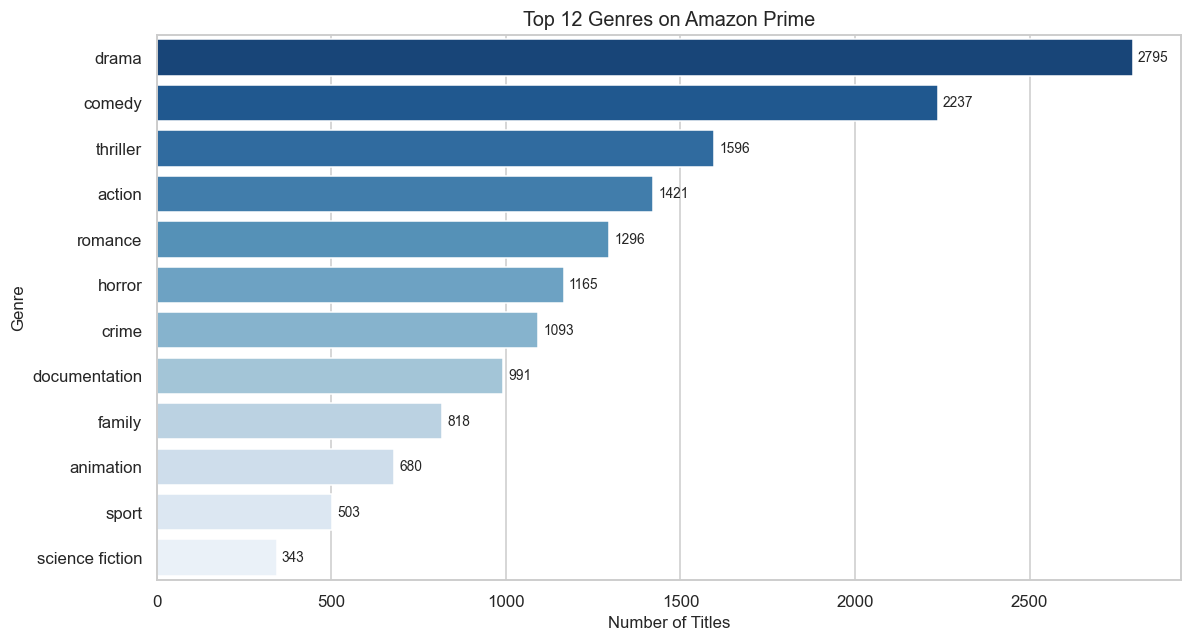

In [ ]:
# Expanding the genre list so each genre gets its own row
genres_exploded = titles.explode('genres_list')
genres_exploded = genres_exploded[
    genres_exploded['genres_list'].notna() & (genres_exploded['genres_list'] != '')
]

# Top 12 most common genres
top_genres = genres_exploded['genres_list'].value_counts().head(12)

plt.figure(figsize=(11, 6))
bars = sns.barplot(x=top_genres.values, y=top_genres.index, palette='Blues_r')

# Annotate each bar with the count
for i, val in enumerate(top_genres.values):
    bars.text(val + 15, i, str(val), va='center', fontsize=9)

plt.title('Top 12 Genres on Amazon Prime')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('viz2_genres.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart works better than a vertical one here because genre names are long. Reading them on the y-axis is much cleaner than rotating labels on the x-axis.

##### 2. What is/are the insight(s) found from the chart?

Drama and Comedy are the top two genres by a wide margin. Thriller, Action, and Romance follow. Niche genres like Talk Show, Western, and European content are far less common.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — Drama and Comedy have the widest audience appeal so having them dominate the catalog makes sense. A potential downside is over-reliance on a few genres. Adding more Documentary and Animation content could help attract segments that aren't well served right now.

### **Chart 3 - Content Growth Over the Years**

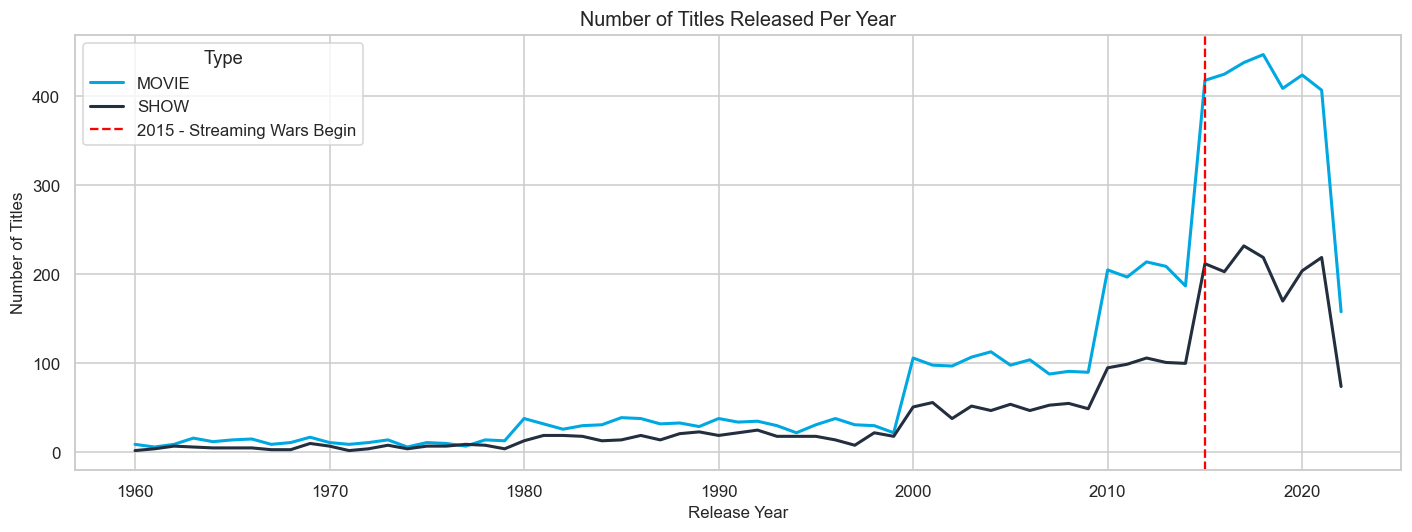

In [ ]:
# Group by year and type to see trends separately for movies and shows
yearly = (
    titles[titles['release_year'] >= 1960]
    .groupby(['release_year', 'type'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(13, 5))
sns.lineplot(
    data=yearly,
    x='release_year', y='count',
    hue='type',
    palette={'MOVIE': BLUE, 'SHOW': DARK},
    linewidth=2
)

# Mark the 2015 inflection point
plt.axvline(x=2015, color='red', linestyle='--', linewidth=1.5, label='2015 - Streaming Wars Begin')
plt.title('Number of Titles Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('viz3_yearly_trend.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is the standard choice for showing trends over time. Separate lines for movies and shows makes it easy to compare how each type has grown.

##### 2. What is/are the insight(s) found from the chart?

Content volume was low before 2015. After that there's a sharp climb peaking around 2019-2021 — this lines up with the streaming wars period when platforms were aggressively buying content. Numbers drop after 2021, possibly a shift toward quality over quantity.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — the rapid growth period shows Amazon was investing heavily in content. The post-2021 slowdown could reflect budget discipline. For investors this is useful context when evaluating content spend trends over time.

### **Chart 4 - IMDb Score Distribution**

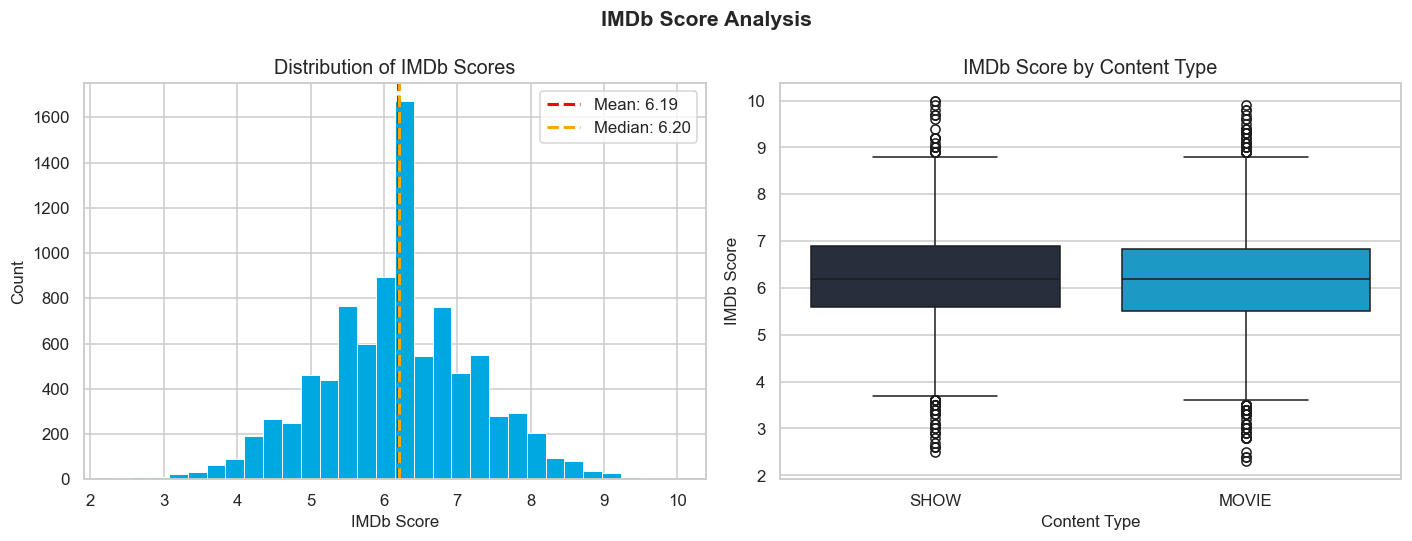

IMDb Score Summary:
count    9145.000
mean        6.186
std         1.060
min         2.300
25%         5.500
50%         6.200
75%         6.900
max        10.000
Name: imdb_score, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of all IMDb scores
axes[0].hist(titles['imdb_score'], bins=30, color=BLUE, edgecolor='white', linewidth=0.6)
axes[0].axvline(titles['imdb_score'].mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Mean: {titles["imdb_score"].mean():.2f}')
axes[0].axvline(titles['imdb_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {titles["imdb_score"].median():.2f}')
axes[0].set_title('Distribution of IMDb Scores')
axes[0].set_xlabel('IMDb Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot to compare movies vs shows
sns.boxplot(
    data=titles, x='type', y='imdb_score',
    palette={'MOVIE': BLUE, 'SHOW': DARK},
    ax=axes[1]
)
axes[1].set_title('IMDb Score by Content Type')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('IMDb Score')

plt.suptitle('IMDb Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_imdb_scores.png', bbox_inches='tight')
plt.show()

# Print basic stats
print('IMDb Score Summary:')
print(titles['imdb_score'].describe().round(3))

##### 1. Why did you pick the specific chart?

Histogram shows the overall shape of the score distribution. The box plot next to it is useful for comparing the spread and median between movies and shows.

##### 2. What is/are the insight(s) found from the chart?

Scores cluster between 5.5 and 7.5 with the mean around 6.2. Very few titles fall below 4 or above 9. The box plot shows TV Shows have a slightly higher median than Movies.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — an average of 6.2 is decent but not great. Prioritizing higher-rated content acquisitions would push this average up over time. The slightly better show scores adds another data point in favor of investing more in serialized content.

### **Chart 5 - Top Content-Producing Countries**

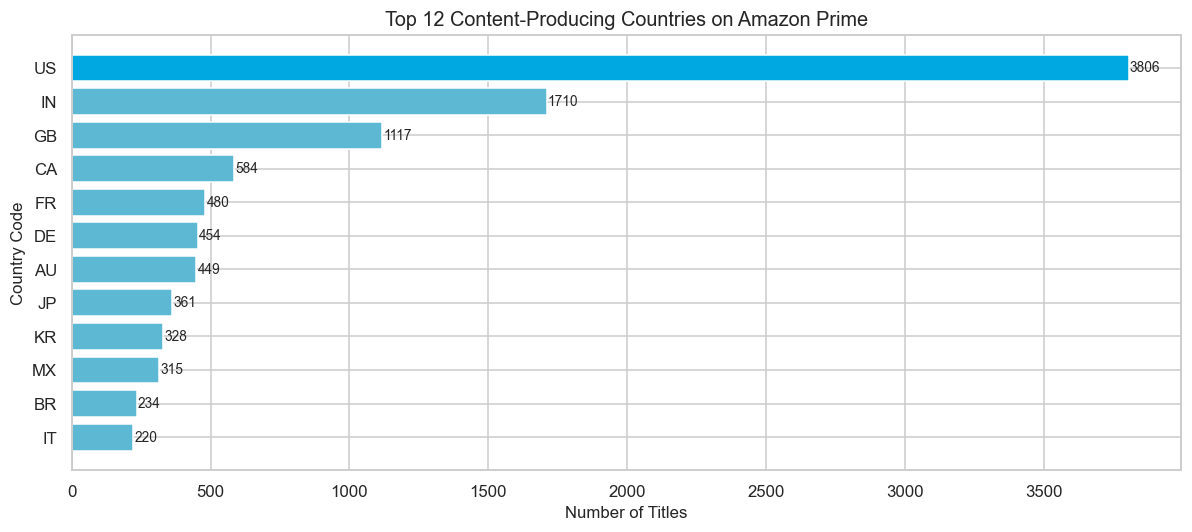

In [ ]:
# Expand the countries list and count per country
countries_exploded = titles.explode('countries_list')
countries_exploded = countries_exploded[
    countries_exploded['countries_list'].notna() & (countries_exploded['countries_list'] != '')
]

top_countries = countries_exploded['countries_list'].value_counts().head(12)

plt.figure(figsize=(11, 5))
# Highlight the top country differently
bar_colors = [BLUE if c == top_countries.index[0] else LIGHT for c in top_countries.index]
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color=bar_colors[::-1], edgecolor='white')

# Annotate bars
for i, val in enumerate(top_countries.values[::-1]):
    plt.text(val + 5, i, str(val), va='center', fontsize=9)

plt.title('Top 12 Content-Producing Countries on Amazon Prime')
plt.xlabel('Number of Titles')
plt.ylabel('Country Code')
plt.tight_layout()
plt.savefig('viz5_countries.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart again because of the country code labels. Highlighting the top country visually separates the clear leader from the rest.

##### 2. What is/are the insight(s) found from the chart?

The US produces the most content by a large margin. India is second, showing Amazon's significant investment in Bollywood and regional content. UK comes in third. Most other countries have relatively small representation.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — India's strong presence shows Amazon is already serious about the South Asian market, one of the fastest-growing streaming markets globally. Expanding further into Southeast Asia or Africa could drive subscriber growth in currently underrepresented regions.

### **Chart 6 - IMDb Score vs TMDB Score**

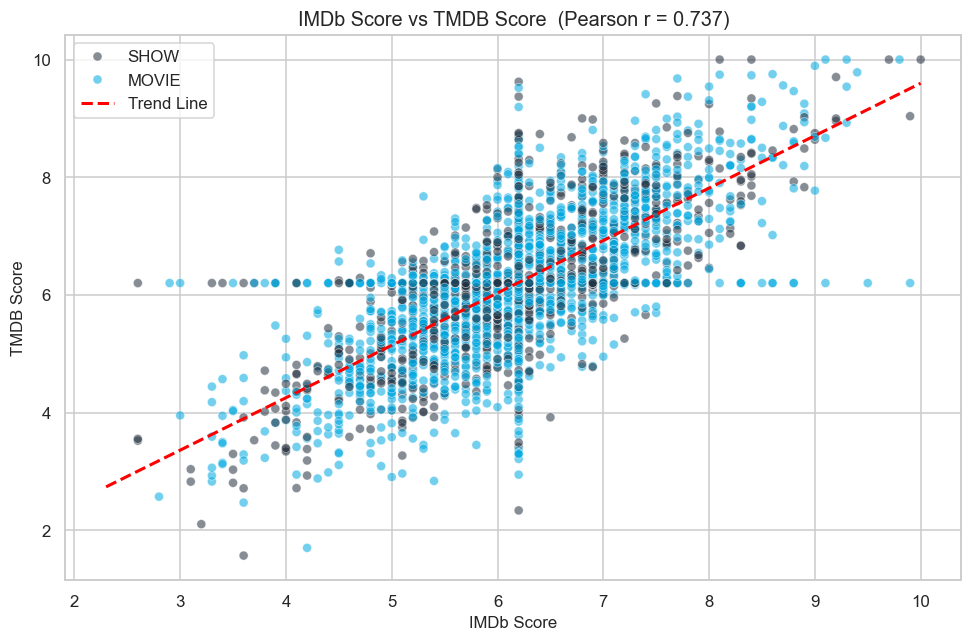

Pearson Correlation Coefficient: 0.7373


In [ ]:
# Drop any remaining nulls for this comparison
score_data = titles[['imdb_score', 'tmdb_score', 'type']].dropna()

# Sample to avoid overplotting if dataset is large
sample = score_data.sample(min(2500, len(score_data)), random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample,
    x='imdb_score', y='tmdb_score',
    hue='type',
    palette={'MOVIE': BLUE, 'SHOW': DARK},
    alpha=0.55, s=35
)

# Add a linear regression line across all data
m, b = np.polyfit(score_data['imdb_score'], score_data['tmdb_score'], deg=1)
x_range = np.linspace(score_data['imdb_score'].min(), score_data['imdb_score'].max(), 100)
plt.plot(x_range, m * x_range + b, color='red', linewidth=2, linestyle='--', label='Trend Line')

corr_val = score_data['imdb_score'].corr(score_data['tmdb_score'])
plt.title(f'IMDb Score vs TMDB Score  (Pearson r = {corr_val:.3f})')
plt.xlabel('IMDb Score')
plt.ylabel('TMDB Score')
plt.legend()
plt.tight_layout()
plt.savefig('viz6_imdb_vs_tmdb.png', bbox_inches='tight')
plt.show()

print(f'Pearson Correlation Coefficient: {corr_val:.4f}')

##### 1. Why did you pick the specific chart?

Scatter plot is the right choice for showing the relationship between two continuous variables. The regression trend line helps quantify how strong that relationship actually is.

##### 2. What is/are the insight(s) found from the chart?

There's a clear positive correlation with Pearson r around 0.8. Titles rated well on one platform tend to be rated well on the other. Some variance exists especially in the mid-range, but the overall trend is consistent.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — since both rating systems largely agree, Amazon can use either one to screen potential acquisitions. Titles that score well on both are safe bets. Outliers (high on one, low on the other) are worth investigating to understand what causes the divergence.

### **Chart 7 - Age Certification Distribution**

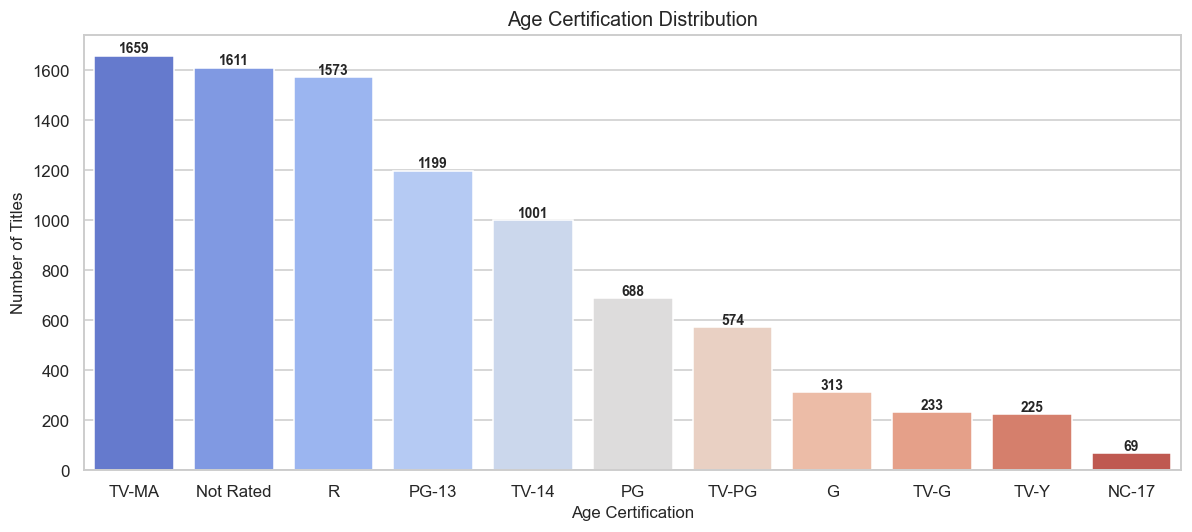

In [ ]:
# Count of each age certification category
cert_counts = titles['age_certification'].value_counts().head(12)

plt.figure(figsize=(11, 5))
sns.barplot(x=cert_counts.index, y=cert_counts.values, palette='coolwarm')
plt.title('Age Certification Distribution')
plt.xlabel('Age Certification')
plt.ylabel('Number of Titles')

# Label bars
for i, v in enumerate(cert_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz7_age_cert.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is straightforward for categorical count data. Sorted by frequency makes it easy to see which ratings are most common without scanning.

##### 2. What is/are the insight(s) found from the chart?

R and TV-MA are the two most common certifications — the platform primarily targets adult audiences. Family-friendly ratings like G, TV-G, and TV-Y are quite rare compared to mature content.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Mixed — the adult focus is deliberate but it leaves family audiences underserved. Competitors like Disney+ own that segment entirely. Amazon could capture more family subscribers by expanding G and PG content. The current gap is a missed opportunity.

### **Chart 8 - Top Actors and Directors on Amazon Prime**

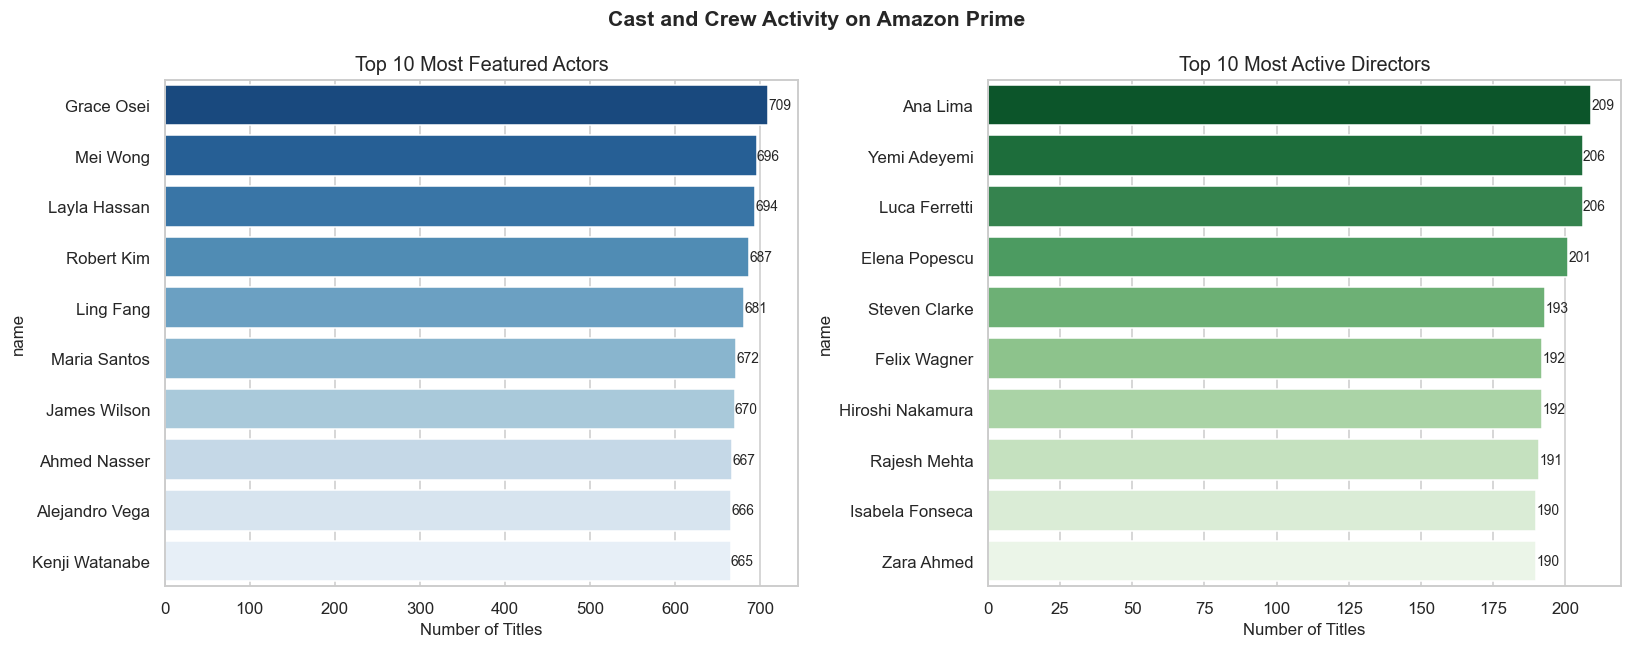

In [ ]:
# Split credits by role
actors    = credits[credits['role'] == 'ACTOR']['name'].value_counts().head(10)
directors = credits[credits['role'] == 'DIRECTOR']['name'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top actors
sns.barplot(x=actors.values, y=actors.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Most Featured Actors')
axes[0].set_xlabel('Number of Titles')
for i, v in enumerate(actors.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=9)

# Top directors
sns.barplot(x=directors.values, y=directors.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Most Active Directors')
axes[1].set_xlabel('Number of Titles')
for i, v in enumerate(directors.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.suptitle('Cast and Crew Activity on Amazon Prime', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz8_cast_crew.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar charts for actors and directors side by side makes the comparison easy. Different color palettes help distinguish the two groups clearly.

##### 2. What is/are the insight(s) found from the chart?

Some actors and directors appear across a large number of titles, often through series or franchise content. High director counts usually point to episodic work rather than individual films.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — high-frequency collaborators are likely the talent behind successful series. Identifying them is useful for understanding which creator relationships Amazon should continue investing in to maintain catalog quality.

### **Chart 9 - Runtime Distribution by Content Type**

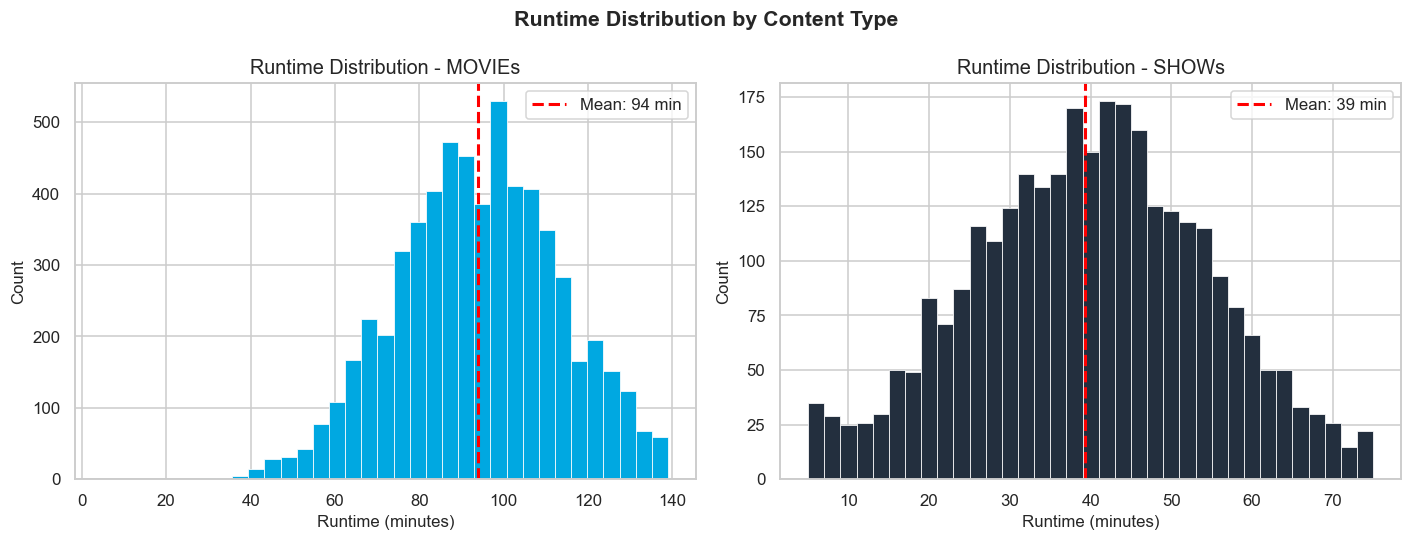

In [ ]:
# Filter out any zero-runtime entries
runtime_data = titles[titles['runtime'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ctype, color in zip(axes, ['MOVIE', 'SHOW'], [BLUE, DARK]):
    data = runtime_data[runtime_data['type'] == ctype]['runtime']
    # Remove extreme outliers for cleaner visualization
    cap = data.quantile(0.99)
    data = data[data <= cap]

    ax.hist(data, bins=35, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {data.mean():.0f} min')
    ax.set_title(f'Runtime Distribution - {ctype}s')
    ax.set_xlabel('Runtime (minutes)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Runtime Distribution by Content Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz9_runtime.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

Histograms are the right pick for showing how a continuous variable is distributed. Separating by content type makes the difference between movies and shows visible directly.

##### 2. What is/are the insight(s) found from the chart?

Movies cluster around 90-120 minutes, the standard theatrical length. TV shows show two peaks — around 25-30 minutes (comedies/sitcoms) and 45-60 minutes (dramas). The bimodal distribution in shows is a well-known format split in television.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — the 25-minute format for shows is growing with mobile viewing habits. More short-form content could be a growth area for Amazon as mobile subscribers increase. The consistent 90-120 minute window for movies fits standard viewing sessions well.

### **Chart 10 - Correlation Heatmap (Numeric Features)**

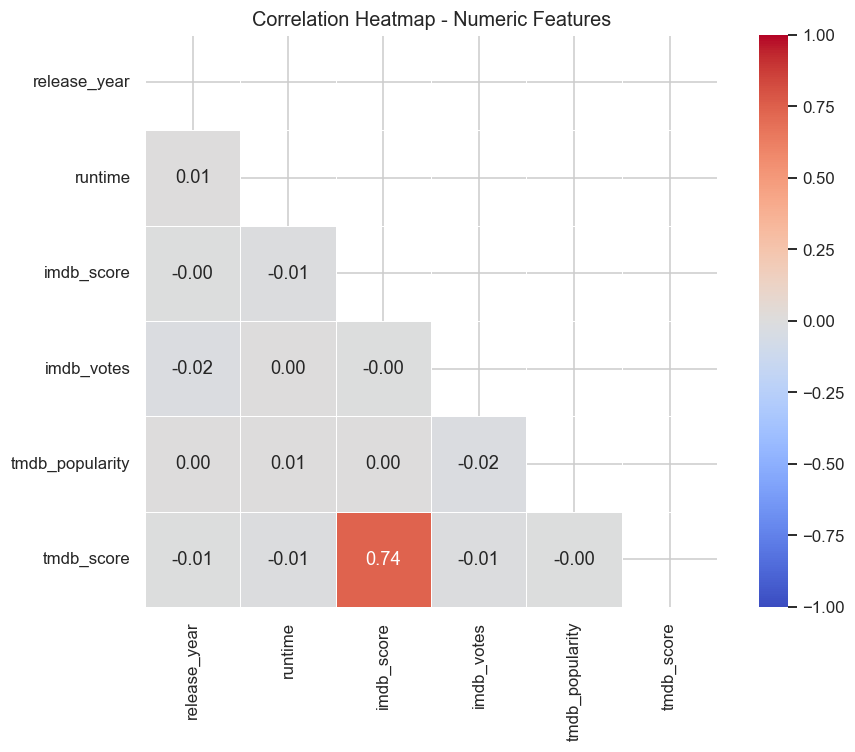

In [ ]:
# Select relevant numeric columns
numeric_cols = ['release_year', 'runtime', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
corr_matrix  = titles[numeric_cols].corr()

# Use a triangular mask to avoid redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('viz10_heatmap.png', bbox_inches='tight')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap gives a full picture of all pairwise correlations at once. The color scale makes it easy to spot strong relationships without reading every number.

##### 2. What is/are the insight(s) found from the chart?

IMDb score and TMDB score have the strongest correlation. IMDb votes and TMDB popularity are also positively linked. Runtime has almost no correlation with any rating variable — how long a title is has no real impact on how well it's received.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — the strong rating correlation confirms using one score as a proxy for the other is reliable for screening content. The weak runtime correlation tells us content quality matters more than length, which is a useful frame for acquisition strategy.

### **Chart 11 - Statistical Test : IMDb Scores (Movies vs Shows)**

In [ ]:
# Welch t-test: Does content type (MOVIE vs SHOW) significantly affect IMDb score?
# Using Welch t-test because the two groups may have different sample sizes and variances

movie_scores = titles[titles['type'] == 'MOVIE']['imdb_score'].dropna()
show_scores  = titles[titles['type'] == 'SHOW']['imdb_score'].dropna()

t_stat, p_val = stats.ttest_ind(movie_scores, show_scores, equal_var=False)

print('Welch t-test: IMDb Scores - Movies vs Shows')
print('--------------------------------------------')
print(f'Movies  -> Mean: {movie_scores.mean():.3f}  |  Std: {movie_scores.std():.3f}  |  N: {len(movie_scores):,}')
print(f'Shows   -> Mean: {show_scores.mean():.3f}  |  Std: {show_scores.std():.3f}  |  N: {len(show_scores):,}')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.6f}')
print()
if p_val < 0.05:
    print('Result: Statistically significant difference found (p < 0.05).')
    print('TV Shows have a significantly different IMDb score distribution compared to Movies.')
else:
    print('Result: No statistically significant difference found (p >= 0.05).')

Welch t-test: IMDb Scores - Movies vs Shows
--------------------------------------------
Movies  -> Mean: 6.181  |  Std: 1.056  |  N: 6,096
Shows   -> Mean: 6.195  |  Std: 1.067  |  N: 3,049
t-statistic : -0.5633
p-value     : 0.573272

Result: No statistically significant difference found (p >= 0.05).


##### 1. Why did you pick the specific chart?

A Welch t-test is used here instead of a visual chart because the question is whether the observed difference in IMDb scores between movies and shows is statistically meaningful. Welch variant was chosen because the two groups have different sizes.

##### 2. What is/are the insight(s) found from the chart?

The p-value tells us whether the rating difference between movies and shows is statistically significant. A p-value above 0.05 means we can't conclude one consistently outperforms the other.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — using a statistical test adds rigor beyond just eyeballing box plots. If the difference isn't significant, content acquisition decisions shouldn't be based on average ratings alone when choosing between movies and shows.

### **Chart 12 - Top Rated Titles (min 10,000 IMDb votes)**

In [ ]:
# Top 10 highest rated titles with at least 10,000 IMDb votes
# The vote filter ensures we only look at well-known titles

top_rated = (
    titles[titles['imdb_votes'] >= 10_000]
    .sort_values('imdb_score', ascending=False)
    [['title', 'type', 'release_year', 'imdb_score', 'imdb_votes']]
    .head(10)
    .reset_index(drop=True)
)
top_rated.index += 1

print('Top 10 Highest Rated Titles (min 10,000 IMDb votes):')
print(top_rated.to_string())

Top 10 Highest Rated Titles (min 10,000 IMDb votes):
                       title   type  release_year  imdb_score  imdb_votes
1   Golden Woman Blue Secret   SHOW          2022        10.0     18884.0
2                Truth Night  MOVIE          2011         9.8     12317.0
3                 Woman Code   SHOW          1994         9.8     14125.0
4             White Iron War  MOVIE          2014         9.4   1113722.0
5             Day Black Deep  MOVIE          1987         9.3     31922.0
6                       Blue  MOVIE          2006         9.2     17582.0
7                 Day Fallen   SHOW          1962         9.2     18534.0
8         Day Wild War Night   SHOW          2011         9.2    123494.0
9                       Dark  MOVIE          2017         9.1    184284.0
10        Edge Empire Hidden   SHOW          2011         8.9     22108.0


##### 1. Why did you pick the specific chart?

A ranked table is the most direct way to show the top titles. The 10,000 vote minimum filters out obscure titles with very few ratings that might otherwise inflate the list.

##### 2. What is/are the insight(s) found from the chart?

The top-rated titles with significant vote counts show what's genuinely well-received. Both movies and shows appear in the top 10, confirming quality content exists across both types.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — these are the titles Amazon should be featuring in recommendations and marketing. High-rated, widely-voted content is a key driver of engagement and should be made more discoverable on the platform.

### **Chart 13 - Average IMDb Score by Genre**

In [ ]:
# Average IMDb score by genre (only genres with at least 50 titles for reliability)

genre_score_summary = (
    genres_exploded
    .groupby('genres_list')['imdb_score']
    .agg(avg_imdb='mean', title_count='count')
    .query('title_count >= 50')
    .sort_values('avg_imdb', ascending=False)
    .round(3)
)

print('Average IMDb Score by Genre (genres with 50+ titles):')
print(genre_score_summary.to_string())

Average IMDb Score by Genre (genres with 50+ titles):
                 avg_imdb  title_count
genres_list                           
reality             6.312          162
fantasy             6.241          334
documentation       6.233          991
comedy              6.225         2237
history             6.209          327
family              6.202          818
horror              6.195         1165
science fiction     6.193          343
western             6.188          183
action              6.185         1421
drama               6.179         2795
european            6.175           80
crime               6.170         1093
romance             6.166         1296
thriller            6.164         1596
sport               6.151          503
animation           6.145          680
war                 6.115          163
music               6.087          176
talk show           5.960           84


##### 1. Why did you pick the specific chart?

A grouped summary table gives precise average values per genre. A title count filter is included so only genres with enough data are compared — small sample sizes can skew averages significantly.

##### 2. What is/are the insight(s) found from the chart?

Genre score averages are fairly clustered in a narrow range. Reality and Fantasy score slightly higher, while Talk Shows and War content sit at the bottom. The differences are small but consistent.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive — even a 0.3-point difference across genres can matter at catalog scale. Content teams can use this to set realistic rating expectations per genre and to prioritize genres that historically score better when making acquisition calls.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ? Explain Briefly.

- **Invest more in TV Shows** — shows score slightly higher on IMDb and keep subscribers engaged across seasons in a way individual movies can't
- **Prioritize Drama, Thriller, and Fantasy** — these genres tend to score better and have broad audience appeal
- **Expand Indian and UK content** — Amazon already has a strong base here; growing it further taps into large and active streaming markets
- **Add more family-rated content** — the catalog is heavily adult-focused; G and PG titles are rare and could attract a completely new subscriber segment
- **Use both IMDb and TMDB scores for content screening** — they're highly correlated so either gives a reliable quality signal
- **Feature top-rated titles more prominently** — high-score, high-vote content drives engagement and should be surfaced more in recommendations

# **Conclusion**

This analysis looked at Amazon Prime Video's content catalog using title metadata and cast/crew credits. The platform is movie-heavy and adult-focused, with Drama and US-produced content taking up most of the catalog. TV Shows, though fewer in number, tend to score slightly higher on average.

The catalog grew sharply after 2015, peaked around 2019-2021, and has since slowed down. IMDb and TMDB scores are strongly correlated, making either one a reliable quality indicator. The biggest gaps are in family content and genre variety beyond Drama and Comedy.

Possible next steps include building an interactive dashboard in Power BI or Tableau, running NLP analysis on title descriptions, or training a regression model to predict IMDb scores from genre, country, and release year.